In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

0.5 5 1.515746 1.5156893632249897


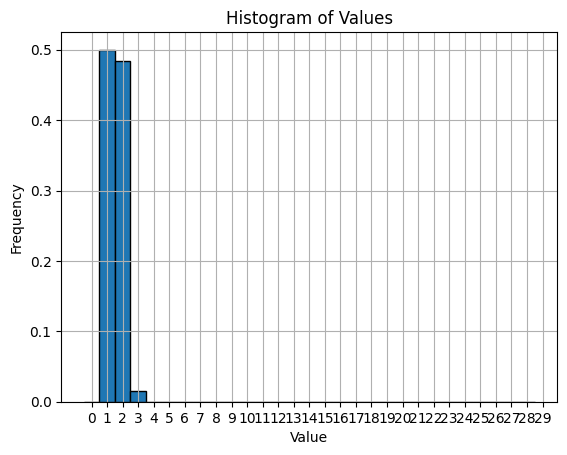

0.2 10 1.200167 1.2000781255292217


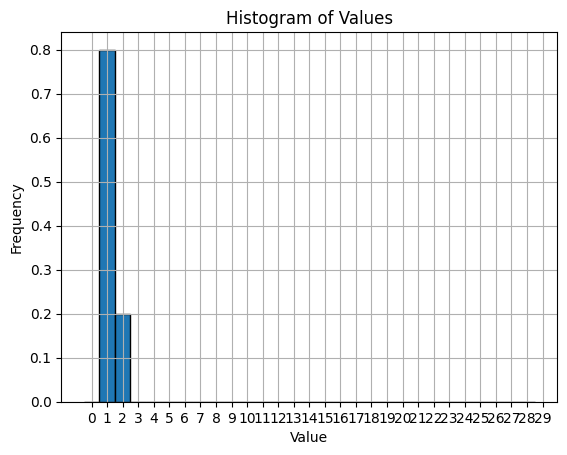

0.5 0.5 2.231853 2.234753157260524


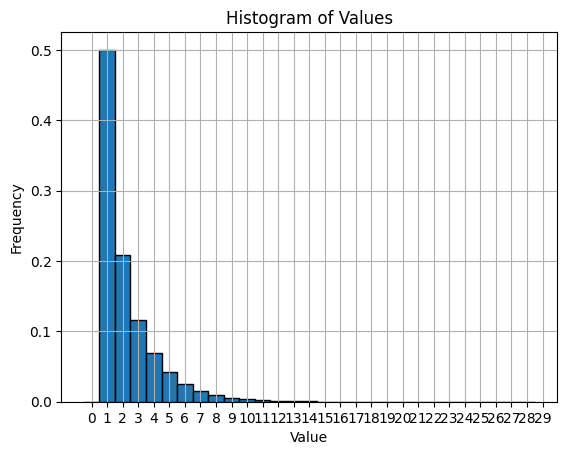

0.95 0.5 9.645146 9.639850891999897


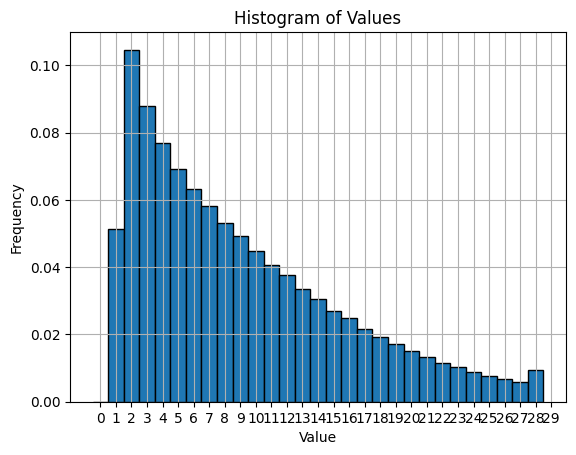

0.95 1 3.842612 3.8429472211396343


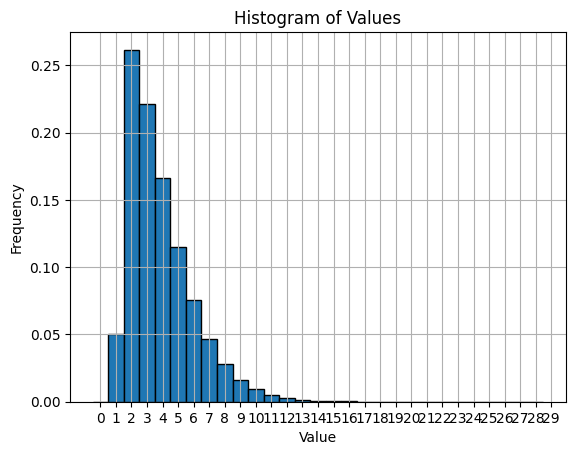

0.95 1.5 2.888088 2.8877038321347843


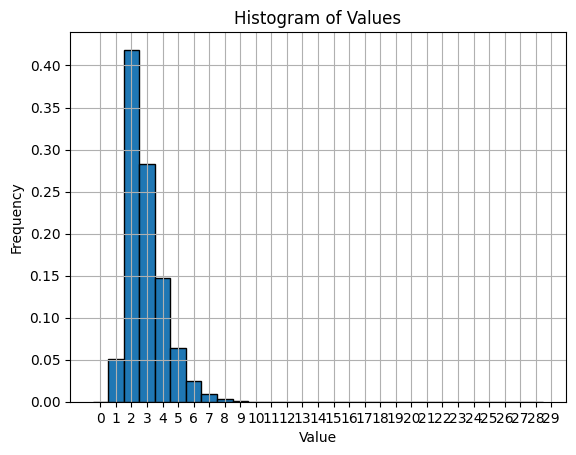

0.95 2 2.509151 2.508733421296946


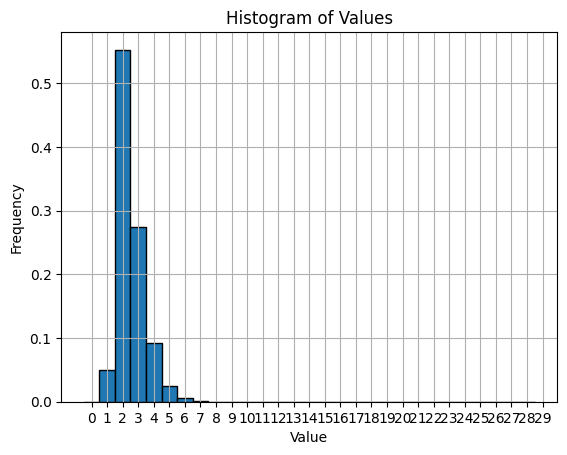

0.99 5 2.051999 2.0517563407166266


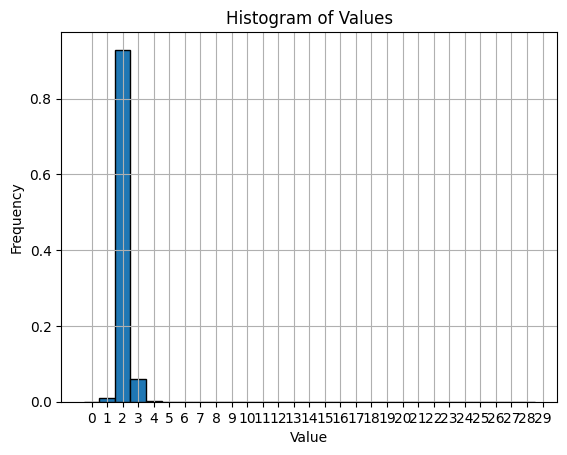

0.99 10 1.991844 1.9919143220005069


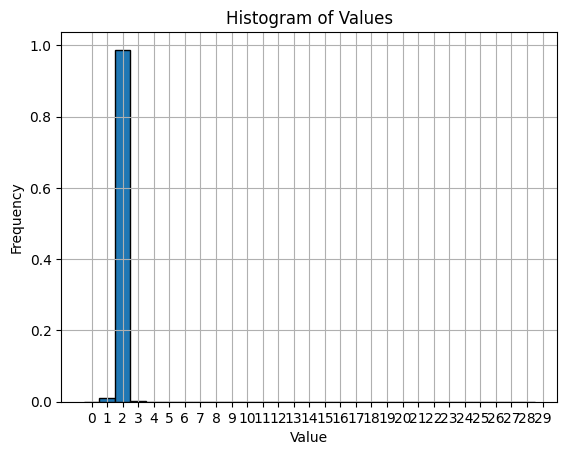

In [2]:
psplit = lambda d, a, b : a*(1+d)**(-b)
psplit_a_b = lambda a, b : lambda d : psplit(d, a, b)

def expected_leaves(a, b, max_depth=1000):
    E = [1.0] * (max_depth + 1)  # Initialize with base case: E[max_depth] = 1
    
    for d in reversed(range(max_depth)):
        p_split = a * (1 + d)**(-b)
        E[d] = (1 - p_split) + 2 * p_split * E[d + 1]
        
    return E[0]

def get_res(a, b):
    prob_a_b = [psplit_a_b(a, b)(i) for i in range(0, 1000)]
    def get_rec_num(d):
        # root
        if random.random() <= prob_a_b[d]:
            return get_rec_num(d + 1) + get_rec_num(d + 1)
        else:
            return 1

    n = 1000000
    res = []
    for i in range(n):
        d = 0

        r = get_rec_num(d) 
        res.append(r)
    return res

for a, b in [#(2, 0.5),
             (0.5, 5),
             (0.2, 10),
             (0.5, 0.5),
             (0.95, 0.5),
             (0.95, 1),
             (0.95, 1.5),
             (0.95, 2),
             (0.99, 5),
             (0.99, 10)]:
    res = get_res(a, b)
    print(a, b, np.mean(res), expected_leaves(a, b))

    plt.hist(res, bins=range(0, 30), edgecolor='black', align='left',
            density=True)

    # Add labels and title
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    plt.title('Histogram of Values')
    plt.grid(True)
    plt.xticks(range(0,30))

    # Show plot
    plt.show()

In [7]:
a, b = (0.95, 2)
print([(d, psplit(d, a, b)) for d in range(0, 11)])

[(0, 0.95), (1, 0.2375), (2, 0.10555555555555554), (3, 0.059375), (4, 0.038), (5, 0.026388888888888885), (6, 0.019387755102040813), (7, 0.01484375), (8, 0.011728395061728394), (9, 0.0095), (10, 0.007851239669421488)]
